In [17]:
%cd /Users/joshlee/Desktop/biolab_work/shtrahman_lab

/Users/joshlee/Desktop/biolab_work/shtrahman_lab


In [ ]:
import pysam
import numpy as np
import matplotlib.pyplot as plt
from Bio.Seq import Seq
from collections import Counter
from freq_analysis import frequency_pipeline

In [43]:
%cd all_data

[Errno 2] No such file or directory: 'all_data'
/Users/joshlee/Desktop/biolab_work/shtrahman_lab/all_data


# Recheck forward/reverse orientation 

In [29]:
egfp = (
    "ATGGTGAGCAAGGGCGAGGAGCTGTTCACCGGGGTGGTGCCCATCCTGGTCGAGCTGGACGGCGACGTAAACGGCCACAAGTTCAGCGTGTCCGGCGAGGGCGAGGGCGATGCCACCTACGGCAAGCTGACCCTGAAGTTCATCTGCACCACCGGCAAGCTGCCCGTGCCCTGGCCCACCCTCGTGACCACCCTGACCTACGGCGTGCAGTGCTTCAGCCGCTACCCCGACCACATGAAGCAGCACGACTTCTTCAAGTCCGCCATGCCCGAAGGCTACGTCCAGGAGCGCACCATCTTCTTCAAGGACGACGGCAACTACAAGACCCGCGCCGAGGTGAAGTTCGAGGGCGACACCCTGGTGAACCGCATCGAGCTGAAGGGCATCGACTTCAAGGAGGACGGCAACATCCTGGGGCACAAGCTGGAGTACAACTACAACAGCCACAACGTCTATATCATGGCCGACAAGCAGAAGAACGGCATCAAGGTGAACTTCAAGATCCGCCACAACATCGAGGACGGCAGCGTGCAGCTCGCCGACCACTACCAGCAGAACACCCCCATCGGCGACGGCCCCGTGCTGCTGCCCGACAACCACTACCTGAGCACCCAGTCCGCCCTGAGCAAAGACCCCAACGAGAAGCGCGATCACATGGTCCTGCTGGAGTTCGTGACCGCCGCCGGGATCACTCTCGGCATGGACGAGCTGTACAAGTAA"
)
egfp_rc = str(Seq(egfp).reverse_complement())

#25 length kmers
K = 25
kmers = [egfp[i:i+K] for i in range(len(egfp)-K+1)]
counts = Counter(kmers)
unique_kmers = [k for k in kmers if counts[k] == 1]
unique_kmers_rc = [str(Seq(k).reverse_complement()) for k in unique_kmers]
print(f"{len(unique_kmers)} unique {K}-mers generated.")

def check_orientation(bamfile):
    bam = pysam.AlignmentFile(bamfile)
    counts = {
        "forward": 0,
        "reverse": 0,
        "none": 0
    }
    agreement = 0
    disagreement = 0

    for read in bam.fetch():
        if read.is_unmapped:
            continue
        raw = read.get_forward_sequence()
        if raw is None:
            continue
        raw = raw.upper()
        f_hits = 0
        r_hits = 0

        # Count unique marker hits
        for fwd, rev in zip(unique_kmers, unique_kmers_rc):
            if fwd in raw:
                f_hits += 1
            if rev in raw:
                r_hits += 1
        if f_hits > r_hits:
            counts["forward"] += 1
            predicted = "forward"
        elif r_hits > f_hits:
            counts["reverse"] += 1
            predicted = "reverse"
        else:
            counts["none"] += 1
            predicted = None
        if predicted is not None:
            bam_orientation = "reverse" if read.is_reverse else "forward"

            if predicted == bam_orientation:
                agreement += 1
            else:
                disagreement += 1
    total = sum(counts.values())
    classified = counts["forward"] + counts["reverse"]

    print("\n==============================")
    print(f"BAM: {bamfile}")
    print("==============================")
    print(f"Total reads examined : {total:,}")
    print(f"Forward EGFP : {counts['forward']:,} ({100*counts['forward']/total:.2f}%)")
    print(f"Reverse EGFP : {counts['reverse']:,} ({100*counts['reverse']/total:.2f}%)")
    print(f"No EGFP evidence : {counts['none']:,} ({100*counts['none']/total:.2f}%)")

    if classified > 0:
        print("\nAgreement with BAM strand flag")
        print(f"Agreement    : {agreement:,} ({100*agreement/classified:.2f}%)")
        print(f"Disagreement : {disagreement:,} ({100*disagreement/classified:.2f}%)")

    return counts

696 unique 25-mers generated.


In [31]:
check_orientation('sense_strand_analysis/wt/wt_forward.bam')
check_orientation('sense_strand_analysis/wt/wt_reverse.bam')


BAM: sense_strand_analysis/wt/wt_forward.bam
Total reads examined : 2,469
Forward EGFP : 25 (1.01%)
Reverse EGFP : 5 (0.20%)
No EGFP evidence : 2,439 (98.78%)

Agreement with BAM strand flag
Agreement    : 25 (83.33%)
Disagreement : 5 (16.67%)

BAM: sense_strand_analysis/wt/wt_reverse.bam
Total reads examined : 1,854
Forward EGFP : 2 (0.11%)
Reverse EGFP : 29 (1.56%)
No EGFP evidence : 1,823 (98.33%)

Agreement with BAM strand flag
Agreement    : 29 (93.55%)
Disagreement : 2 (6.45%)


{'forward': 2, 'reverse': 29, 'none': 1823}

In [15]:
check_orientation('sense_strand_analysis/dbc_to_wt_alignment/dbc_wt_forward.bam')
check_orientation('sense_strand_analysis/dbc_to_wt_alignment/dbc_wt_reverse.bam')


BAM: sense_strand_analysis/dbc_to_wt_alignment/dbc_wt_forward.bam
Total reads examined : 853
Forward EGFP : 24 (2.81%)
Reverse EGFP : 0 (0.00%)
No EGFP evidence : 829 (97.19%)

Agreement with BAM strand flag
Agreement    : 24 (100.00%)
Disagreement : 0 (0.00%)

BAM: sense_strand_analysis/dbc_to_wt_alignment/dbc_wt_reverse.bam
Total reads examined : 732
Forward EGFP : 0 (0.00%)
Reverse EGFP : 19 (2.60%)
No EGFP evidence : 713 (97.40%)

Agreement with BAM strand flag
Agreement    : 19 (100.00%)
Disagreement : 0 (0.00%)


{'forward': 0, 'reverse': 19, 'none': 713}

In [32]:
check_orientation('sense_strand_analysis/hybrid_wt_alignment/hybrid_wt_forward.bam')
check_orientation('sense_strand_analysis/hybrid_wt_alignment/hybrid_wt_reverse.bam')


BAM: sense_strand_analysis/hybrid_wt_alignment/hybrid_wt_forward.bam
Total reads examined : 1,736
Forward EGFP : 63 (3.63%)
Reverse EGFP : 4 (0.23%)
No EGFP evidence : 1,669 (96.14%)

Agreement with BAM strand flag
Agreement    : 63 (94.03%)
Disagreement : 4 (5.97%)

BAM: sense_strand_analysis/hybrid_wt_alignment/hybrid_wt_reverse.bam
Total reads examined : 749
Forward EGFP : 0 (0.00%)
Reverse EGFP : 77 (10.28%)
No EGFP evidence : 672 (89.72%)

Agreement with BAM strand flag
Agreement    : 77 (100.00%)
Disagreement : 0 (0.00%)


{'forward': 0, 'reverse': 77, 'none': 672}

File 1: sense_strand_analysis/dbc_to_wt_alignment/dbc_to_wt_nopmll_final.bam
Unmapped Reads: 0             
Zero Length Reads: 0             
Total Reads Analyzed: 0             
Reads Absent from Contig: -1585             
Total Reads Contig: 1585
File 2: sense_strand_analysis/wt/wt_nopmll_nanopore_md.bam
Unmapped Reads: 0             
Zero Length Reads: 0             
Total Reads Analyzed: 0             
Reads Absent from Contig: -4323             
Total Reads Contig: 4323
File 3: sense_strand_analysis/hybrid_wt_alignment/hybrid_WT_final.bam
Unmapped Reads: 0             
Zero Length Reads: 0             
Total Reads Analyzed: 0             
Reads Absent from Contig: -2485             
Total Reads Contig: 2485


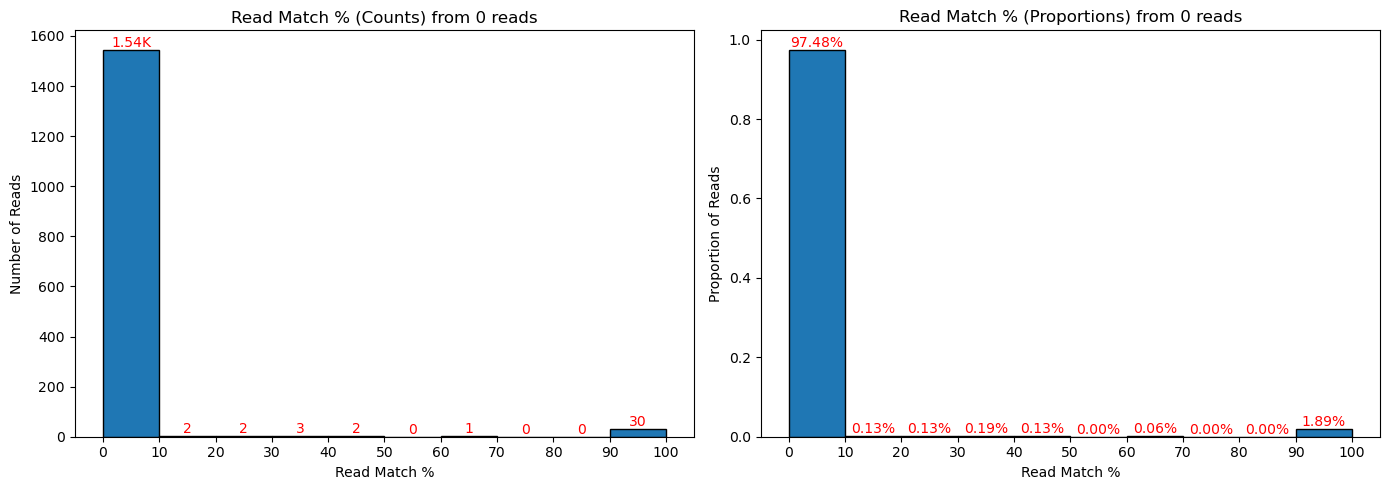

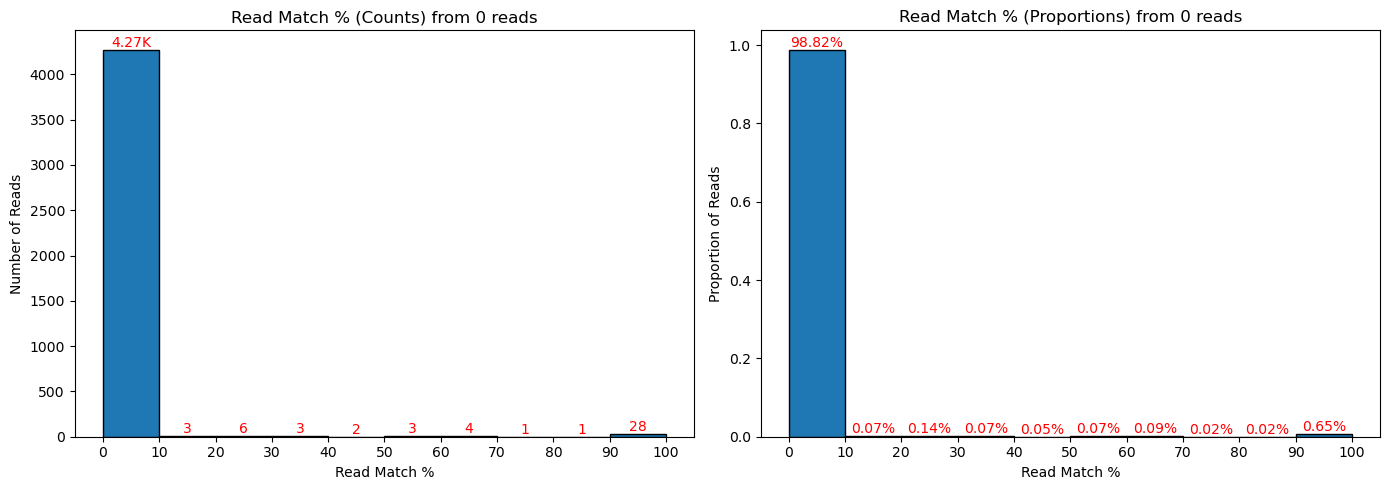

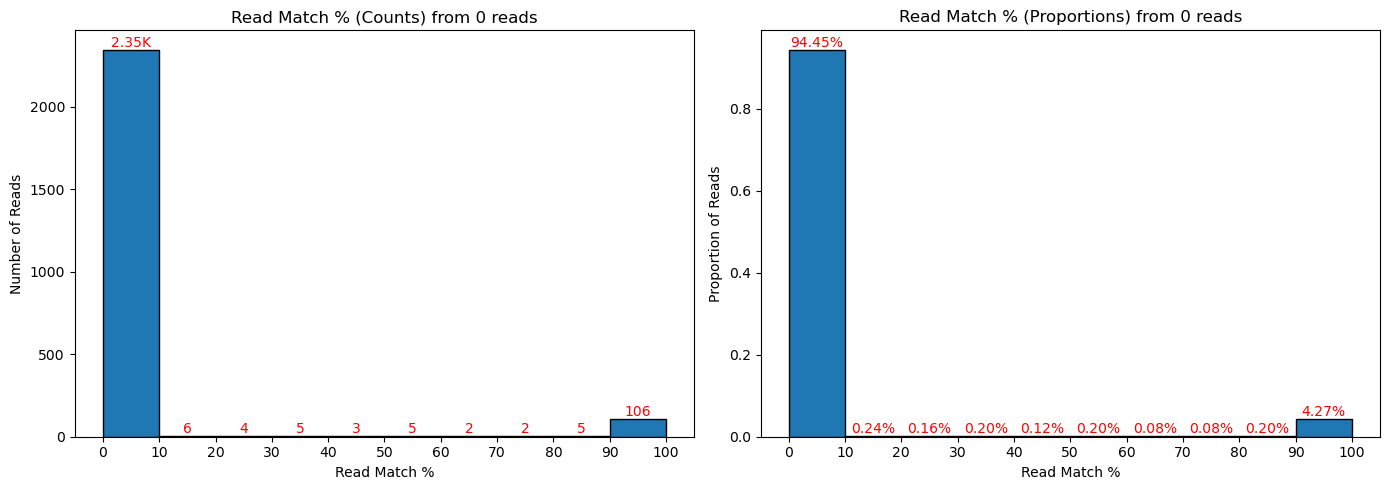

In [45]:
contig = 'B-synITRWT'
start_contig = 0
end_contig = 5018
start_region = 1344
end_region = 2063
total_reads = 0
bam1 = "sense_strand_analysis/dbc_to_wt_alignment/dbc_to_wt_nopmll_final.bam"
bam2 = "sense_strand_analysis/wt/wt_nopmll_nanopore_md.bam"
bam3 = "sense_strand_analysis/hybrid_wt_alignment/hybrid_WT_final.bam"
print(f"File 1: {bam1}")
frequency_pipeline(bam1, contig, start_region, end_region, total_reads, start_contig, end_contig, debug = False)
print(f"File 2: {bam2}")
frequency_pipeline(bam2, contig, start_region, end_region, total_reads, start_contig, end_contig, debug = False)
print(f"File 3: {bam3}")
frequency_pipeline(bam3, contig, start_region, end_region, total_reads, start_contig, end_contig, debug = False)

# Generate matched-base histograms by sample and strand.

File 1: sense_strand_analysis/hybrid_wt_alignment/hybrid_wt_forward.bam
Unmapped Reads: 0             
Zero Length Reads: 0             
Total Reads Analyzed: 1736             
Reads Absent from Contig: 0             
Total Reads Contig: 1736
File 2: sense_strand_analysis/hybrid_wt_alignment/hybrid_wt_reverse.bam
Unmapped Reads: 0             
Zero Length Reads: 0             
Total Reads Analyzed: 749             
Reads Absent from Contig: 0             
Total Reads Contig: 749
File 1: sense_strand_analysis/hybrid_wt_alignment/hybrid_wt_forward.bam
Unmapped Reads: 0             
Zero Length Reads: 0             
Total Reads Analyzed: 1736             
Reads Absent from Contig: 0             
Total Reads Contig: 1736
File 2: sense_strand_analysis/hybrid_wt_alignment/hybrid_wt_reverse.bam
Unmapped Reads: 0             
Zero Length Reads: 0             
Total Reads Analyzed: 749             
Reads Absent from Contig: 0             
Total Reads Contig: 749


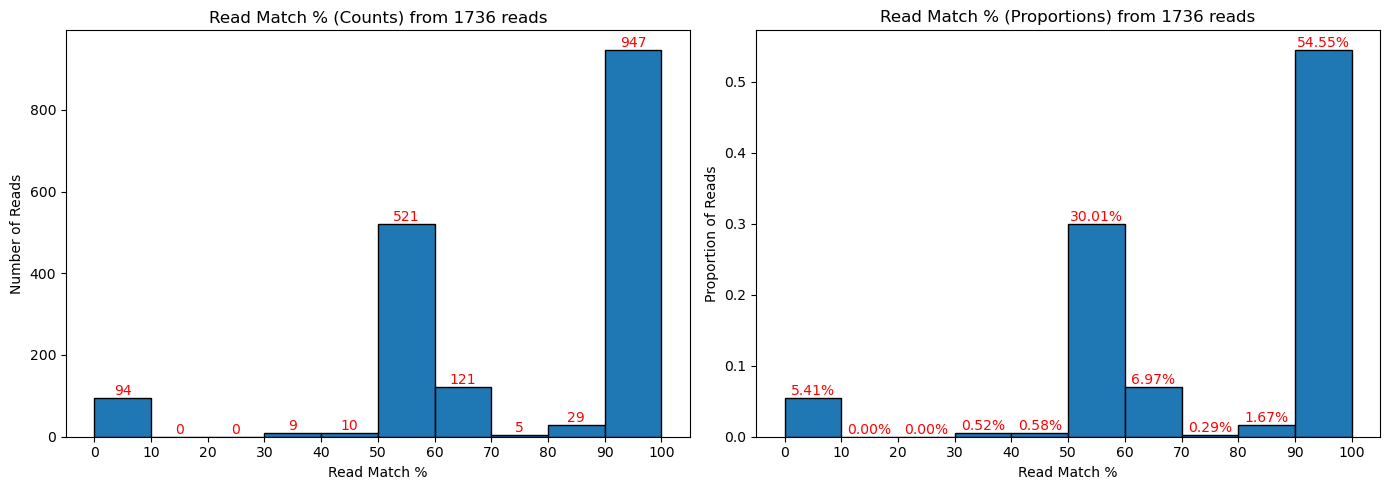

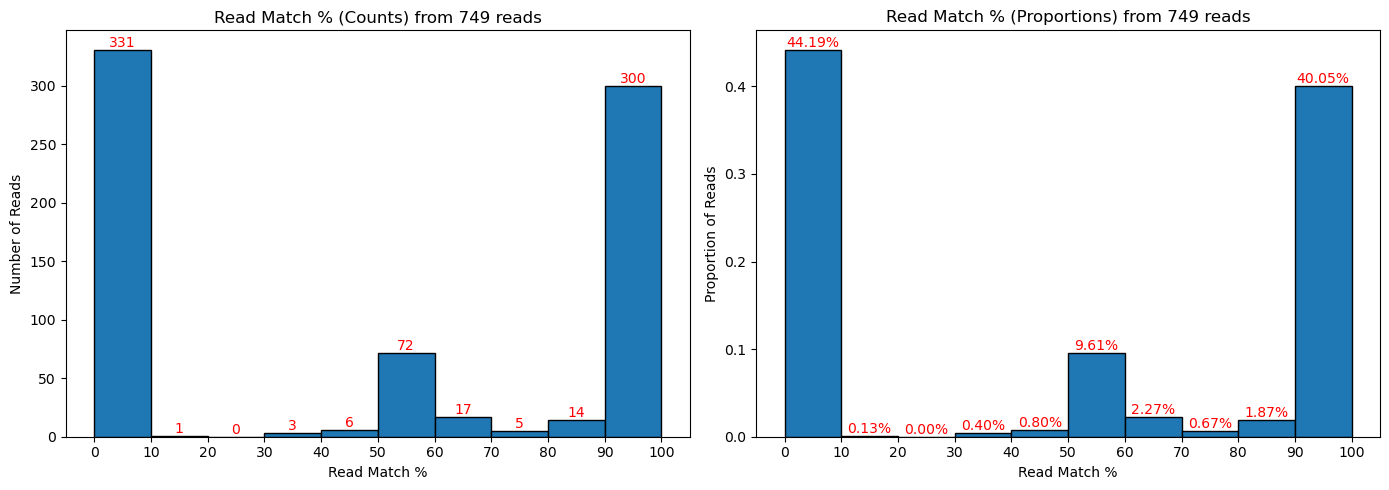

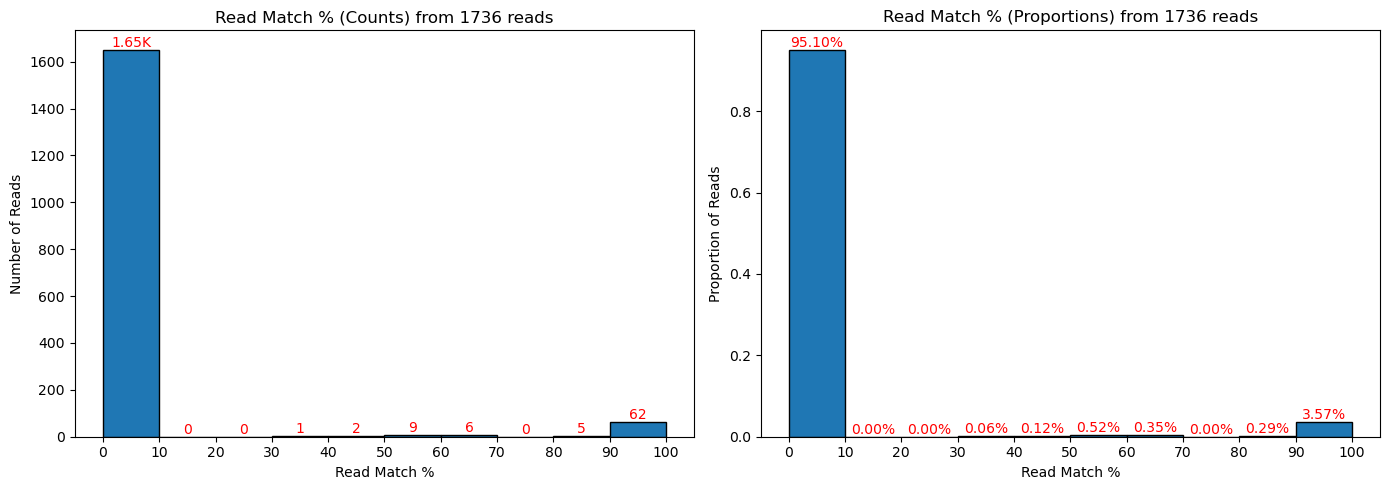

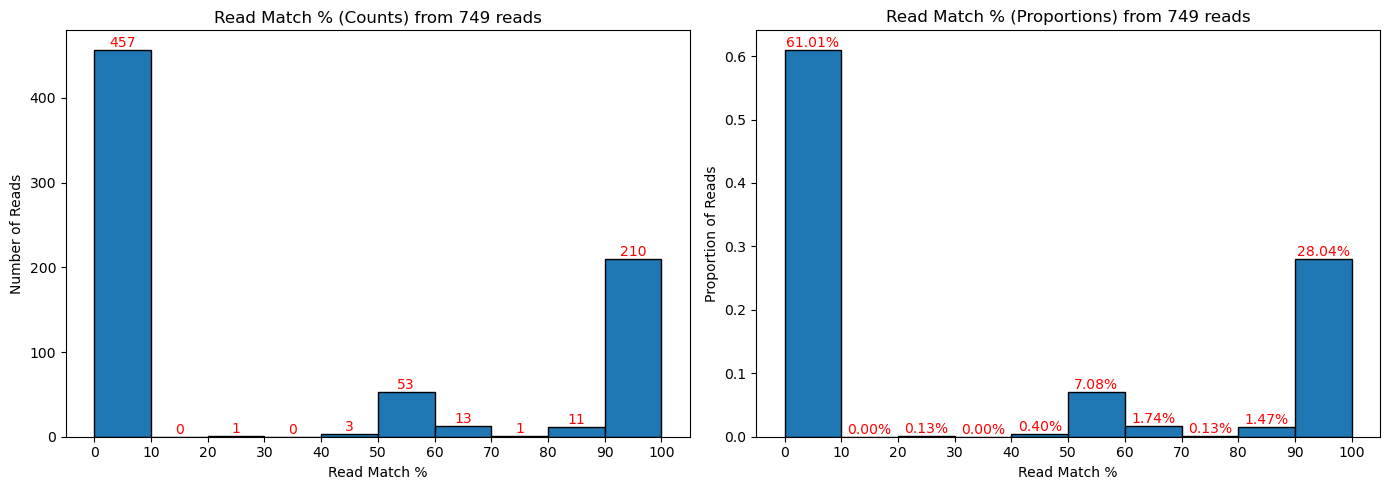

In [52]:
# hybrid wt
start_region = 238
end_region = 273
bam1 = "sense_strand_analysis/hybrid_wt_alignment/hybrid_wt_forward.bam"
bam2 = "sense_strand_analysis/hybrid_wt_alignment/hybrid_wt_reverse.bam"
total_reads_forward = 1736
total_reads_reverse = 749
print(f"File 1: {bam1}")
frequency_pipeline(bam1, contig, start_region, end_region, total_reads_forward, start_contig, end_contig, debug = False)
print(f"File 2: {bam2}")
frequency_pipeline(bam2, contig, start_region, end_region, total_reads_reverse, start_contig, end_contig, debug = False)
start_region = 2988
end_region = 3023
print(f"File 1: {bam1}")
frequency_pipeline(bam1, contig, start_region, end_region, total_reads_forward, start_contig, end_contig, debug = False)
print(f"File 2: {bam2}")
frequency_pipeline(bam2, contig, start_region, end_region, total_reads_reverse, start_contig, end_contig, debug = False)

File 1: sense_strand_analysis/wt/wt_forward.bam
Unmapped Reads: 0             
Zero Length Reads: 0             
Total Reads Analyzed: 2469             
Reads Absent from Contig: 0             
Total Reads Contig: 2469
File 2: sense_strand_analysis/wt/wt_reverse.bam
Unmapped Reads: 0             
Zero Length Reads: 0             
Total Reads Analyzed: 1854             
Reads Absent from Contig: 0             
Total Reads Contig: 1854
File 1: sense_strand_analysis/wt/wt_forward.bam
Unmapped Reads: 0             
Zero Length Reads: 0             
Total Reads Analyzed: 2469             
Reads Absent from Contig: 0             
Total Reads Contig: 2469
File 2: sense_strand_analysis/wt/wt_reverse.bam
Unmapped Reads: 0             
Zero Length Reads: 0             
Total Reads Analyzed: 1854             
Reads Absent from Contig: 0             
Total Reads Contig: 1854


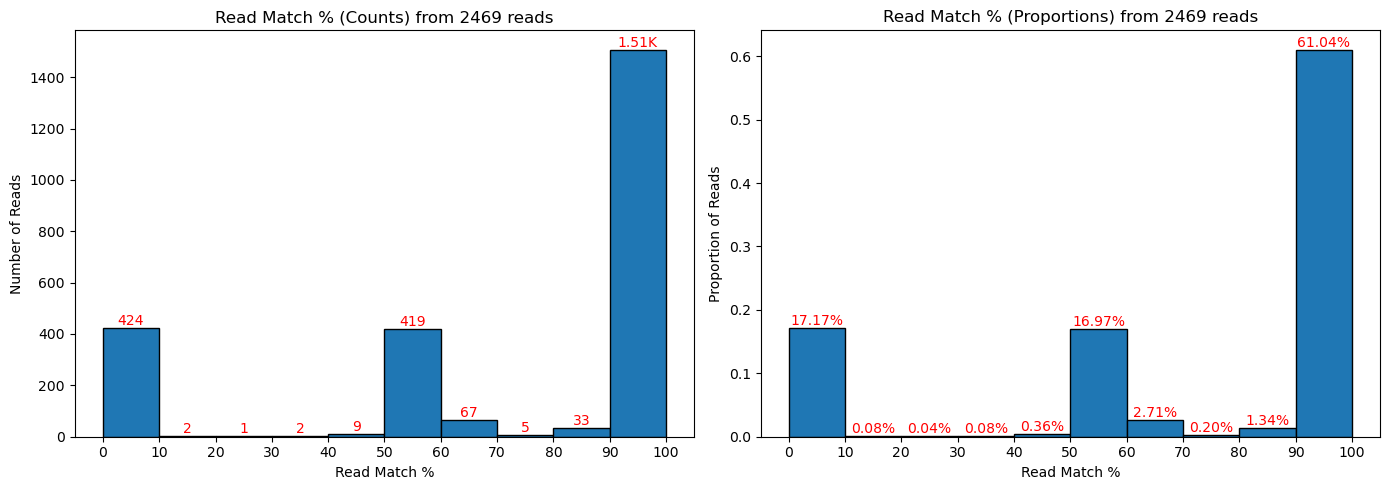

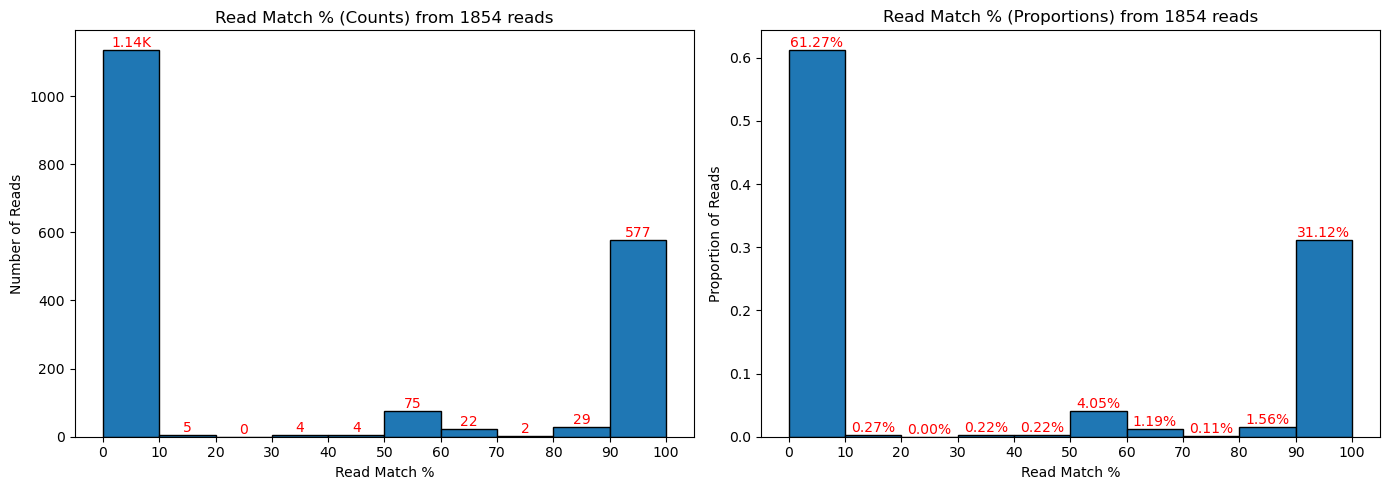

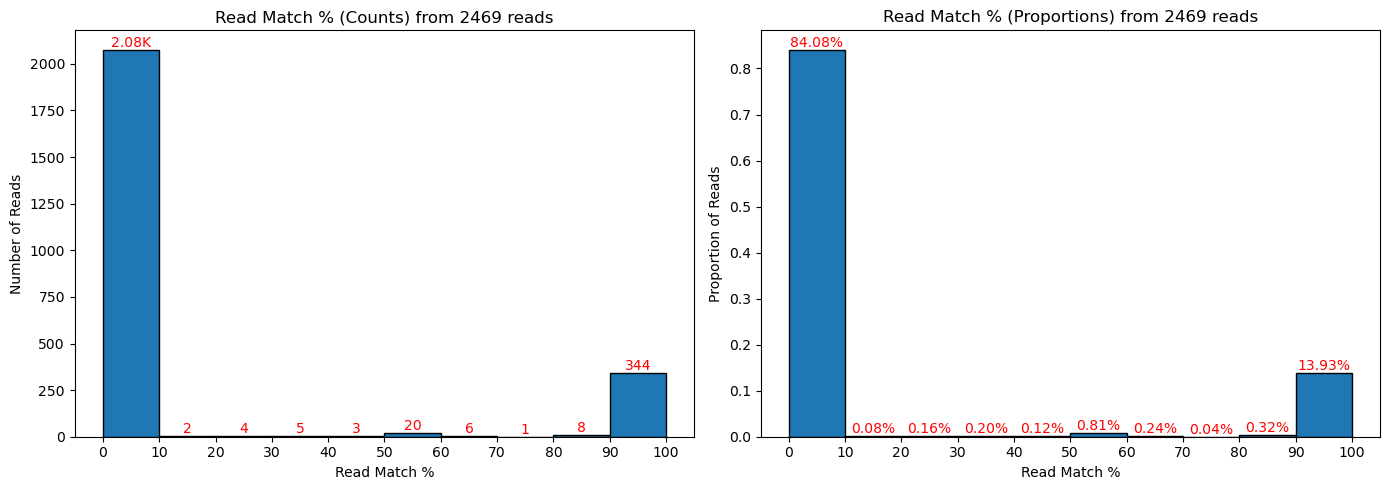

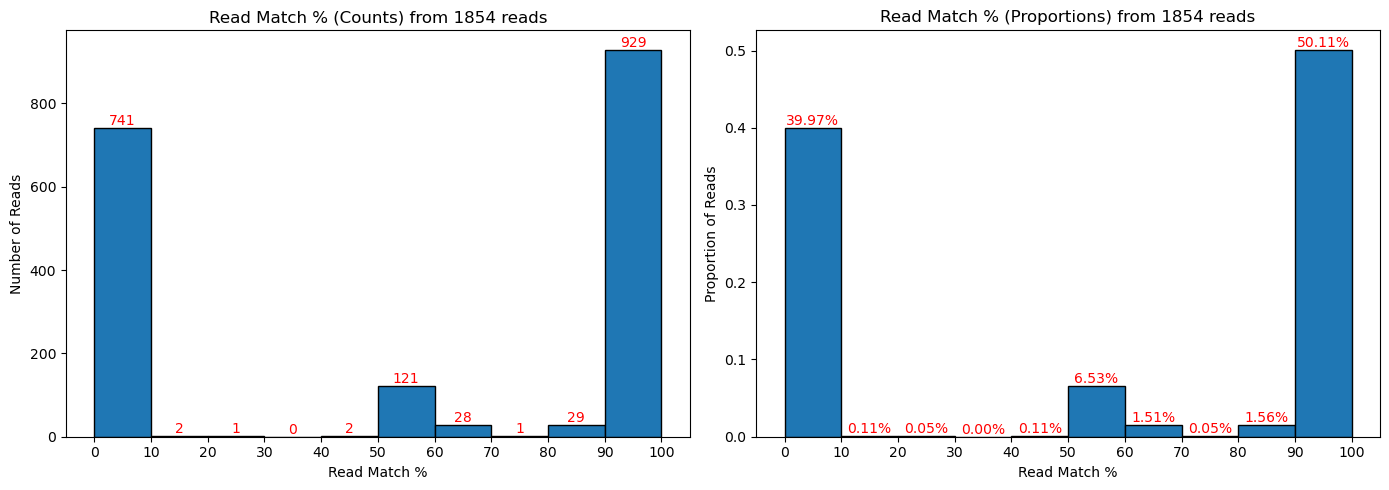

In [ ]:
# WT
start_region = 238
end_region = 273
total_reads_forward = 2469
total_reads_reverse = 1854
bam1 = "sense_strand_analysis/wt/wt_forward.bam"
bam2 = "sense_strand_analysis/wt/wt_reverse.bam"
print(f"File 1: {bam1}")
frequency_pipeline(bam1, contig, start_region, end_region, total_reads_forward, start_contig, end_contig, debug = False)
print(f"File 2: {bam2}")
frequency_pipeline(bam2, contig, start_region, end_region, total_reads_reverse, start_contig, end_contig, debug = False)
start_region = 2988
end_region = 3023
print(f"File 1: {bam1}")
frequency_pipeline(bam1, contig, start_region, end_region, total_reads_forward, start_contig, end_contig, debug = False)
print(f"File 2: {bam2}")
frequency_pipeline(bam2, contig, start_region, end_region, total_reads_reverse, start_contig, end_contig, debug = False)

File 1: sense_strand_analysis/dbc_to_wt_alignment/dbc_wt_forward.bam
Unmapped Reads: 0             
Zero Length Reads: 0             
Total Reads Analyzed: 853             
Reads Absent from Contig: 0             
Total Reads Contig: 853
File 2: sense_strand_analysis/dbc_to_wt_alignment/dbc_wt_reverse.bam
Unmapped Reads: 0             
Zero Length Reads: 0             
Total Reads Analyzed: 732             
Reads Absent from Contig: 0             
Total Reads Contig: 732
File 1: sense_strand_analysis/dbc_to_wt_alignment/dbc_wt_forward.bam
Unmapped Reads: 0             
Zero Length Reads: 0             
Total Reads Analyzed: 853             
Reads Absent from Contig: 0             
Total Reads Contig: 853
File 2: sense_strand_analysis/dbc_to_wt_alignment/dbc_wt_reverse.bam
Unmapped Reads: 0             
Zero Length Reads: 0             
Total Reads Analyzed: 732             
Reads Absent from Contig: 0             
Total Reads Contig: 732


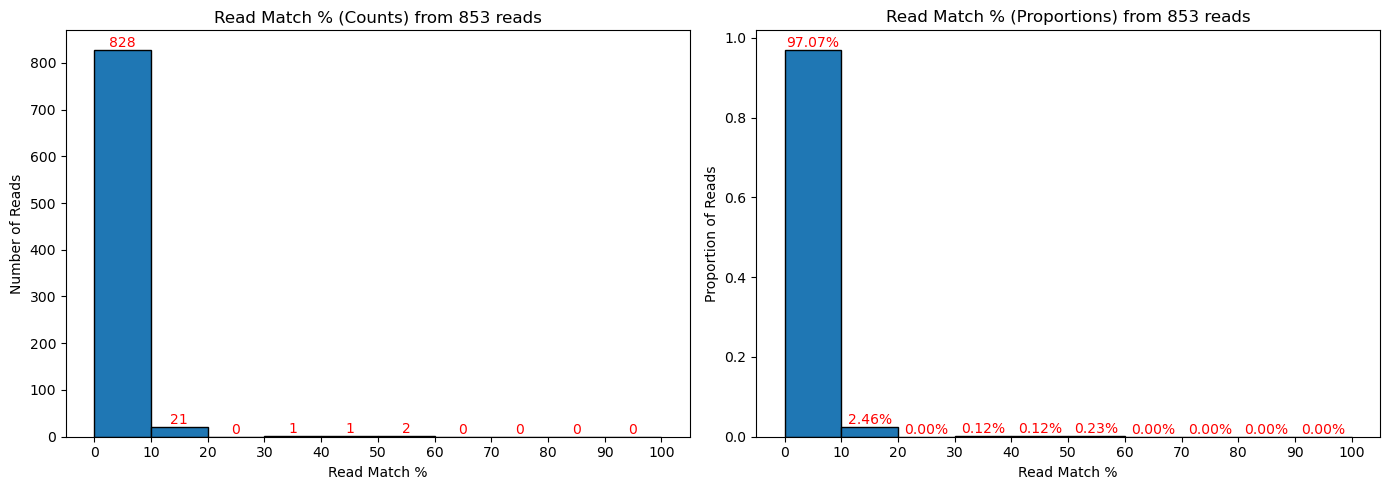

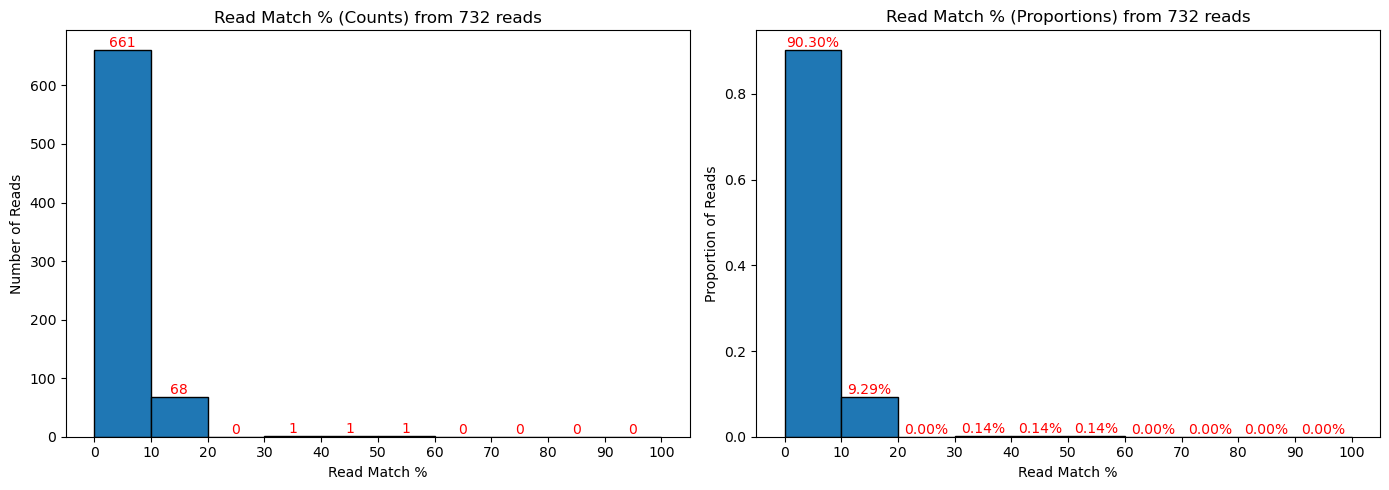

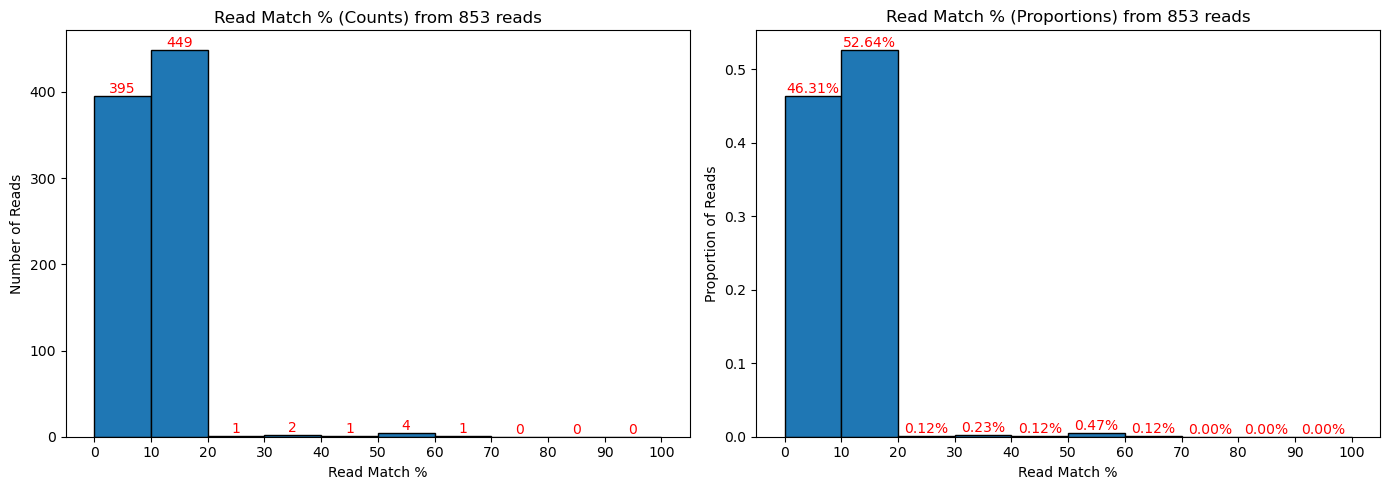

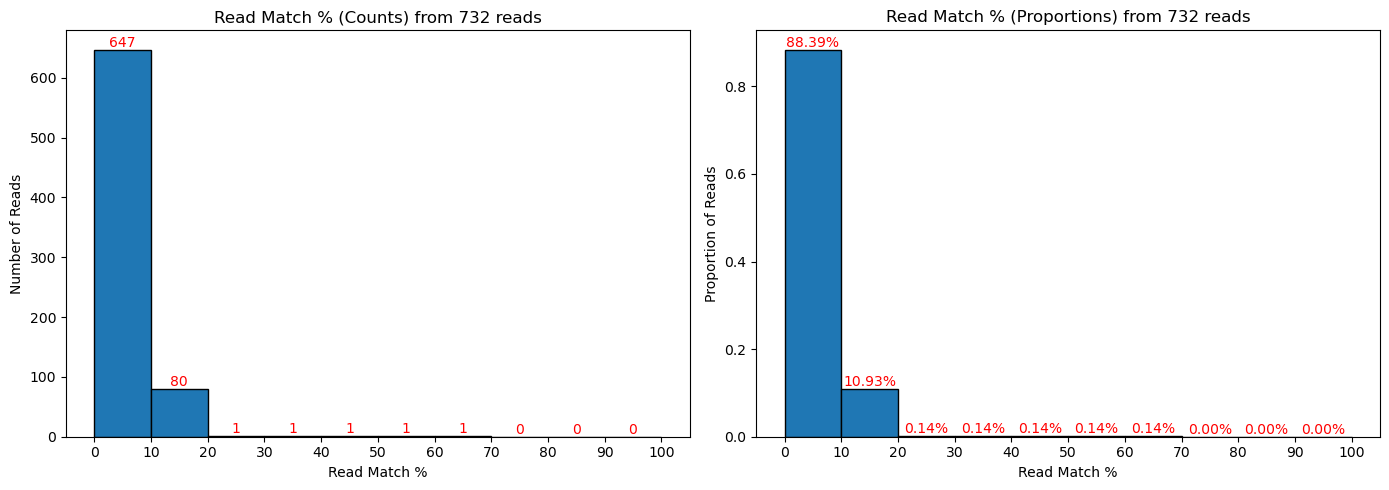

In [51]:
# DBC_Hybrid
start_region = 238
end_region = 273
total_reads_forward = 853
total_reads_reverse = 732
bam1 = "sense_strand_analysis/dbc_to_wt_alignment/dbc_wt_forward.bam"
bam2 = "sense_strand_analysis/dbc_to_wt_alignment/dbc_wt_reverse.bam"
print(f"File 1: {bam1}")
frequency_pipeline(bam1, contig, start_region, end_region, total_reads_forward, start_contig, end_contig, debug = False)
print(f"File 2: {bam2}")
frequency_pipeline(bam2, contig, start_region, end_region, total_reads_reverse, start_contig, end_contig, debug = False)
start_region = 2988
end_region = 3023
print(f"File 1: {bam1}")
frequency_pipeline(bam1, contig, start_region, end_region, total_reads_forward, start_contig, end_contig, debug = False)
print(f"File 2: {bam2}")
frequency_pipeline(bam2, contig, start_region, end_region, total_reads_reverse, start_contig, end_contig, debug = False)

# Quantify full, partial, and absent B/C restoration in hybrid reads

In [70]:
# how many read bases (including insertions, excluding mismatches) map to the region
def count_bc_distr(bamfile: str, bc_region_a: list, bc_region_b: list) -> list:
    bc_a_counts = []
    bc_b_counts = []
    bases = []
    bam = pysam.AlignmentFile(bamfile)
    for read in bam.fetch():
            aligned_bases = 0
            last_ref_pos = None
            pairs = read.get_aligned_pairs(matches_only=False, with_seq=True)
            # normal aligned base
            bc_a_bases = 0
            bc_b_bases = 0

            for query_pos, ref_pos, base in pairs:

                if ref_pos is not None:
                    last_ref_pos = ref_pos

                    if bc_region_a[0] <= ref_pos < bc_region_a[1]:
                        bc_a_bases += 1

                    elif bc_region_b[0] <= ref_pos < bc_region_b[1]:
                        bc_b_bases += 1

                elif ref_pos is None and query_pos is not None:

                    if (
                        last_ref_pos is not None
                        and bc_region_a[0] <= last_ref_pos < bc_region_a[1]
                        and base is not None
                        and not base.islower()
                    ):
                        bc_a_bases += 1

                    elif (
                        last_ref_pos is not None
                        and bc_region_b[0] <= last_ref_pos < bc_region_b[1]
                        and base is not None
                        and not base.islower()
                    ):
                        bc_b_bases += 1
            bc_a_counts.append(bc_a_bases)
            bc_b_counts.append(bc_b_bases)
    return [bc_a_counts, bc_b_counts]

In [135]:
def bc_proportions(counts):
    forward = counts[0]
    reverse = counts[1]
    counts_a = dict(sorted(dict(Counter(forward)).items(), reverse = True))
    counts_b = dict(sorted(dict(Counter(reverse)).items(), reverse = True))

    sum_a = sum(counts_a.values())
    sum_b = sum(counts_b.values())
    percent_a = {key: round(value / sum_a * 100, 2) for key, value in counts_a.items()}
    percent_b = {key: round(value / sum_a * 100, 2) for key, value in counts_b.items()}
    print(f'BC Counts Uptown: \n{counts_a}')
    print(f'BC Counts Downtown: \n{counts_b}')
    print(f'BC Length Proportions Uptown: \n{percent_a}')
    print(f'BC Length Proportions Downtown: \n{percent_b}')

In [136]:
bc_a = [238,274]
bc_b = [2988, 3024]

In [137]:
bamfile = "sense_strand_analysis/wt/wt_forward.bam"
wt_forward = count_bc_distr(bamfile, bc_a, bc_b)
bc_proportions(wt_forward)

BC Counts Uptown: 
{36: 2042, 8: 1, 6: 1, 5: 1, 0: 424}
BC Counts Downtown: 
{36: 387, 10: 1, 9: 2, 7: 1, 6: 2, 0: 2076}
BC Length Proportions Uptown: 
{36: 82.71, 8: 0.04, 6: 0.04, 5: 0.04, 0: 17.17}
BC Length Proportions Downtown: 
{36: 15.67, 10: 0.04, 9: 0.08, 7: 0.04, 6: 0.08, 0: 84.08}


In [138]:
bamfile = "sense_strand_analysis/wt/wt_reverse.bam"
wt_reverse = count_bc_distr(bamfile, bc_a, bc_b)
bc_proportions(wt_reverse)

BC Counts Uptown: 
{36: 711, 17: 2, 7: 1, 6: 1, 5: 3, 3: 1, 2: 1, 0: 1134}
BC Counts Downtown: 
{36: 1110, 10: 1, 5: 2, 0: 741}
BC Length Proportions Uptown: 
{36: 38.35, 17: 0.11, 7: 0.05, 6: 0.05, 5: 0.16, 3: 0.05, 2: 0.05, 0: 61.17}
BC Length Proportions Downtown: 
{36: 59.87, 10: 0.05, 5: 0.11, 0: 39.97}


In [139]:
bamfile = "sense_strand_analysis/hybrid_wt_alignment/hybrid_WT_forward.bam"
h_wt_forward = count_bc_distr(bamfile, bc_a, bc_b)
bc_proportions(h_wt_forward)

BC Counts Uptown: 
{36: 1642, 0: 94}
BC Counts Downtown: 
{36: 85, 2: 1, 0: 1650}
BC Length Proportions Uptown: 
{36: 94.59, 0: 5.41}
BC Length Proportions Downtown: 
{36: 4.9, 2: 0.06, 0: 95.05}


In [140]:
bamfile = "sense_strand_analysis/hybrid_wt_alignment/hybrid_WT_reverse.bam"
h_wt_reverse = count_bc_distr(bamfile, bc_a, bc_b)
bc_proportions(h_wt_reverse)

BC Counts Uptown: 
{36: 418, 17: 1, 0: 330}
BC Counts Downtown: 
{36: 293, 1: 1, 0: 455}
BC Length Proportions Uptown: 
{36: 55.81, 17: 0.13, 0: 44.06}
BC Length Proportions Downtown: 
{36: 39.12, 1: 0.13, 0: 60.75}


In [141]:
bamfile = "sense_strand_analysis/dbc_to_wt_alignment/dbc_wt_forward.bam"
dbc_wt_forward = count_bc_distr(bamfile, bc_a, bc_b)
bc_proportions(dbc_wt_forward)

BC Counts Uptown: 
{36: 35, 0: 818}
BC Counts Downtown: 
{36: 671, 2: 2, 1: 22, 0: 158}
BC Length Proportions Uptown: 
{36: 4.1, 0: 95.9}
BC Length Proportions Downtown: 
{36: 78.66, 2: 0.23, 1: 2.58, 0: 18.52}


In [142]:
bamfile = "sense_strand_analysis/dbc_to_wt_alignment/dbc_wt_reverse.bam"
dbc_wt_reverse = count_bc_distr(bamfile, bc_a, bc_b)
bc_proportions(dbc_wt_reverse)

BC Counts Uptown: 
{36: 80, 1: 4, 0: 648}
BC Counts Downtown: 
{36: 144, 7: 1, 6: 1, 5: 1, 3: 1, 2: 8, 1: 65, 0: 511}
BC Length Proportions Uptown: 
{36: 10.93, 1: 0.55, 0: 88.52}
BC Length Proportions Downtown: 
{36: 19.67, 7: 0.14, 6: 0.14, 5: 0.14, 3: 0.14, 2: 1.09, 1: 8.88, 0: 69.81}
